✅ CSV limpo carregado
Colunas: ['t_s', 'Vbus_V', 'Vshunt_mV', 'I_mA', 'P_mW', 'Vmeas_V', 'Vbat_V', 'T_C', 'SoC', 'SOC0_OCV', 'Ah_acc']
Linhas: 4485
     t_s  Vbus_V  Vshunt_mV  I_mA  P_mW  Vmeas_V  Vbat_V    T_C      SoC  \
0  0.010   0.012      -0.01  -0.2   0.0   2.0344  4.0688  23.00  0.91675   
1  0.545   0.012      -0.01   0.0   0.0   2.0316  4.0633  23.06  0.91675   
2  1.078   0.012      -0.03  -0.2   0.0   2.0351  4.0703  23.06  0.91675   

   SOC0_OCV  Ah_acc  
0   0.91675    -0.0  
1   0.91675    -0.0  
2   0.91675    -0.0  
SoC0 usado: 0.91675

🎯 VALIDAÇÃO FIRMWARE:
MAE:  0.00005033
RMSE: 0.00104439
MAX:  0.04102360

(5 casas decimais)
MAE:  0.00005
RMSE: 0.00104
MAX:  0.04102


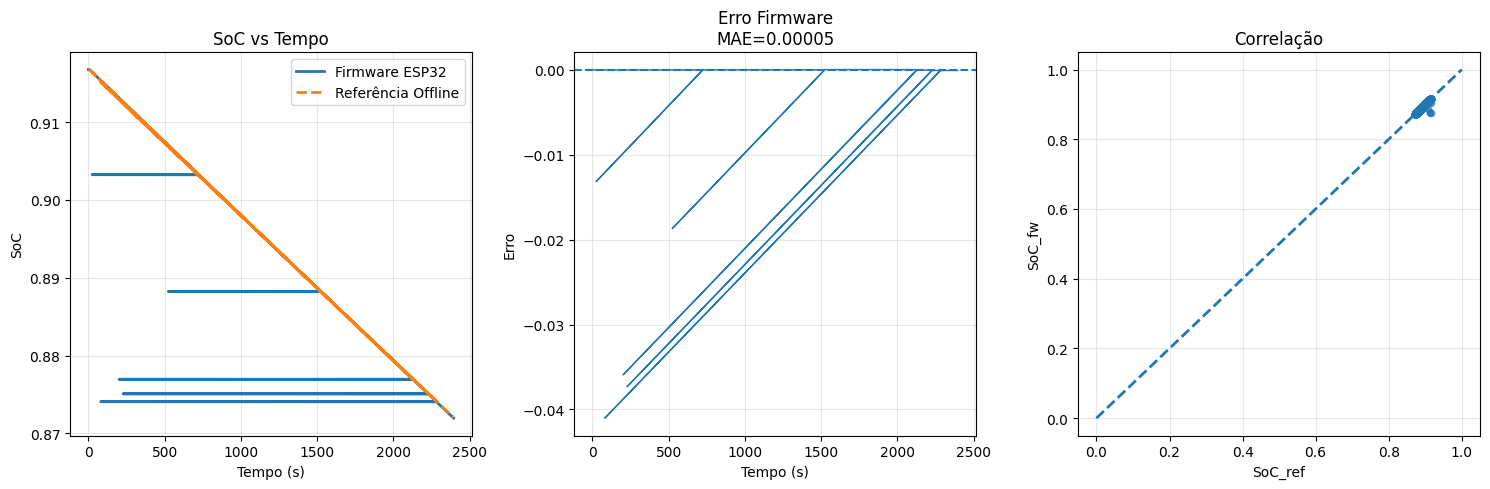


✅ Figura guardada em: /kaggle/working/FIGURA_3_1_VALIDACAO_REAL.png

🔎 Check extra (SoC0 - Ah_acc/C): MAE=0.00000256


In [1]:
# ============================================================
# VALIDAÇÃO REAL (CSV "sujo") — Firmware ESP32 vs Referência Offline
# - Remove linhas de boot/debug que não são CSV
# - Usa header "t_s,..." encontrado no ficheiro
# - Usa SOC0_OCV se existir
# - Recalcula SoC_ref por Coulomb counting
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from io import StringIO

CSV_PATH = "//kaggle/input/soc-logs/log_ina_ads_ds18b20 soc0 ocv.csv"
C_AH = 2.6

# --- 1) Ler tudo como texto ---
with open(CSV_PATH, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.read().splitlines()

# --- 2) Encontrar a linha do header que começa por "t_s," ---
hdr_idx = None
for i, ln in enumerate(lines):
    if ln.strip().startswith("t_s,"):
        hdr_idx = i
        break

if hdr_idx is None:
    raise ValueError("Não encontrei o header 't_s,...' no ficheiro.")

header = lines[hdr_idx].strip()

# --- 3) Filtrar só linhas CSV válidas a partir do header ---
# Mantém:
# - o header
# - linhas que começam por número (ex: 0.510, 12.345) e têm vírgulas
num_csv = re.compile(r"^\s*[-+]?\d+(\.\d+)?,")

good = [header]
expected_cols = header.count(",") + 1

for ln in lines[hdr_idx + 1:]:
    s = ln.strip()
    if not s:
        continue
    if not num_csv.match(s):
        continue
    # garante nº de colunas igual ao header
    if s.count(",") + 1 != expected_cols:
        continue
    good.append(s)

csv_clean = "\n".join(good)

# --- 4) Carregar DataFrame a partir do CSV limpo ---
df = pd.read_csv(StringIO(csv_clean))

print("✅ CSV limpo carregado")
print("Colunas:", df.columns.tolist())
print("Linhas:", len(df))
print(df.head(3))

# --- 5) Colunas SoC ---
soc_col = "SoC" if "SoC" in df.columns else ("SoC_fw" if "SoC_fw" in df.columns else None)
if soc_col is None:
    raise ValueError("Não encontrei a coluna de SoC (esperava 'SoC' ou 'SoC_fw').")

# SoC0
SoC0 = float(df["SOC0_OCV"].iloc[0]) if "SOC0_OCV" in df.columns else float(df[soc_col].iloc[0])
print(f"SoC0 usado: {SoC0:.5f}")

# --- 6) Recalcular SoC_ref ---
dt = df["t_s"].diff().fillna(0.0).to_numpy()
I_A = (df["I_mA"].to_numpy() / 1000.0)

# descarga deve ser positiva -> se mediana negativa, inverter
I_dis_A = -I_A if np.nanmedian(I_A) < 0 else I_A

Ah = np.cumsum(I_dis_A * dt / 3600.0)
df["SoC_ref"] = np.clip(SoC0 - Ah / C_AH, 0.0, 1.0)

# --- 7) Métricas ---
err = df[soc_col] - df["SoC_ref"]
mae = mean_absolute_error(df[soc_col], df["SoC_ref"])
rmse = float(np.sqrt(np.mean(err**2)))
mx = float(np.max(np.abs(err)))

print("\n🎯 VALIDAÇÃO FIRMWARE:")
print(f"MAE:  {mae:.8f}")
print(f"RMSE: {rmse:.8f}")
print(f"MAX:  {mx:.8f}")
print("\n(5 casas decimais)")
print(f"MAE:  {mae:.5f}")
print(f"RMSE: {rmse:.5f}")
print(f"MAX:  {mx:.5f}")

# --- 8) Figuras ---
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.plot(df["t_s"], df[soc_col], linewidth=2, label="Firmware ESP32")
plt.plot(df["t_s"], df["SoC_ref"], "--", linewidth=2, label="Referência Offline")
plt.xlabel("Tempo (s)"); plt.ylabel("SoC"); plt.title("SoC vs Tempo")
plt.grid(True, alpha=0.3); plt.legend()

plt.subplot(1,3,2)
plt.plot(df["t_s"], err, linewidth=1)
plt.axhline(0, linestyle="--")
plt.xlabel("Tempo (s)"); plt.ylabel("Erro"); plt.title(f"Erro Firmware\nMAE={mae:.5f}")
plt.grid(True, alpha=0.3)

plt.subplot(1,3,3)
plt.scatter(df["SoC_ref"], df[soc_col], alpha=0.6, s=20)
plt.plot([0,1],[0,1],"--", linewidth=2)
plt.xlabel("SoC_ref"); plt.ylabel("SoC_fw"); plt.title("Correlação")
plt.grid(True, alpha=0.3)

plt.tight_layout()
OUT = "/kaggle/working/FIGURA_3_1_VALIDACAO_REAL.png"
plt.savefig(OUT, dpi=300, bbox_inches="tight")
plt.show()
print(f"\n✅ Figura guardada em: {OUT}")

# --- 9) Check extra com Ah_acc (se existir) ---
if "Ah_acc" in df.columns and "SOC0_OCV" in df.columns:
    soc_from_ahacc = np.clip(df["SOC0_OCV"].iloc[0] - (df["Ah_acc"] / C_AH), 0.0, 1.0)
    mae2 = mean_absolute_error(df[soc_col], soc_from_ahacc)
    print(f"\n🔎 Check extra (SoC0 - Ah_acc/C): MAE={mae2:.8f}")
